## Import Required Libraries



In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Geospatial
import folium
from folium.plugins import HeatMap

# Model persistence
import joblib

# Utilities
import time
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")


✓ All libraries imported successfully!
XGBoost version: 3.1.2


## Load Dataset

Loads the wireless network dataset from CSV file and performs initial exploratory data analysis. Displays dataset shape, sample rows, and data types to understand the structure and completeness of the SRFG dataset.

In [2]:
# Load dataset
df = pd.read_csv('SRFG-v1.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df):,}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
df.info()


Dataset Shape: (267198, 22)
Total Records: 267,198

First 5 rows:
                  time        lat       long    ele  newpos  rsrq   cell_id  \
0  2018-01-15 16:43:52  47.847847  13.080113  505.1    True  -6.0  798470.0   
1  2018-01-15 16:43:53  47.848070  13.080318  505.2    True  -7.0  798470.0   
2  2018-01-15 16:43:54  47.848280  13.080542  505.5    True  -7.0  798470.0   
3  2018-01-15 16:43:55  47.848484  13.080778  505.7    True  -6.0  798470.0   
4  2018-01-15 16:43:56  47.848680  13.081034  505.8    True  -7.0  798470.0   

   sinr  signal    pci  ...  technology  rsrp   datarate             file  \
0  28.0     5.0  468.0  ...         LTE -65.0  5554624.0  2018-01-15-1736   
1  24.0     5.0  468.0  ...         LTE -68.0  4814816.0  2018-01-15-1736   
2  22.0     5.0  468.0  ...         LTE -67.0  5081632.0  2018-01-15-1736   
3  22.0     5.0  468.0  ...         LTE -70.0  5506112.0  2018-01-15-1736   
4  17.0     5.0  468.0  ...         LTE -77.0  5518240.0  2018-01-15-1736 

## Prepare Data for Modeling

Preprocessing stage that cleans the dataset by removing missing values, defines input features and target variable, and splits data into training (80%) and testing (20%) sets.

In [3]:
# Define features and target
features = ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']
target = 'rsrq'

# Clean dataset - remove missing values
df_clean = df[features + [target, 'lat', 'long']].dropna()

print(f"Clean dataset size: {len(df_clean):,} samples")
print(f"Removed {len(df) - len(df_clean):,} rows with missing values")

# Prepare features and target
X = df_clean[features]
y = df_clean[target]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Save coordinates for heatmap
coords_test = df_clean.loc[y_test.index, ['lat', 'long']].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

print(f"\nTraining samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")
print(f"\nFeatures: {features}")


Clean dataset size: 255,479 samples
Removed 11,719 rows with missing values

Training samples: 204,383
Testing samples: 51,096

Features: ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']


## Analyze Feature Correlations

Computes and visualizes the correlation matrix between all input features and the target variable (RSRQ). Helps identify feature relationships and their individual predictive strength for model development.

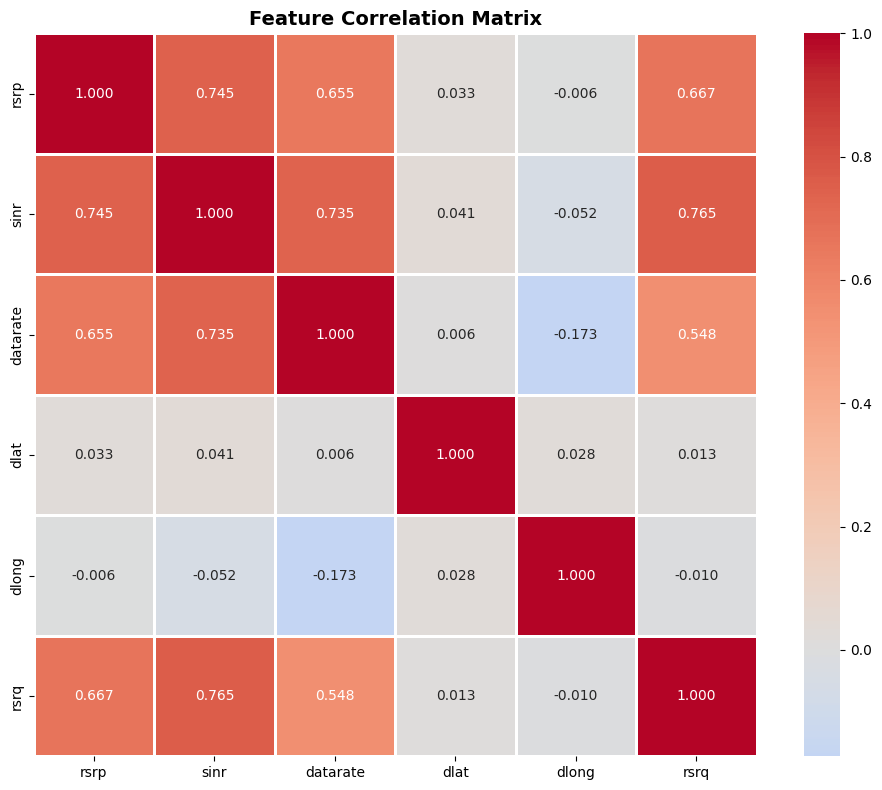


Correlation with RSRQ (Target):
rsrq        1.000000
sinr        0.765178
rsrp        0.666773
datarate    0.547928
dlat        0.013301
dlong      -0.009682
Name: rsrq, dtype: float64


In [4]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_data = df_clean[features + [target]]
corr_matrix = correlation_data.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with RSRQ (Target):")
print(corr_matrix[target].sort_values(ascending=False))


## Train Random Forest Regression Model

Trains the first baseline model using Random Forest with 300 estimators. Computes predictions on test set and evaluates performance using MAE, RMSE, and R² metrics for comparison with other models.

In [5]:
print("="*70)
print("TRAINING RANDOM FOREST MODEL")
print("="*70)

# Random Forest configuration
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,  # Use all CPU cores
    random_state=42,
    verbose=1
)

# Train
print("\nTraining Random Forest...")
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_training_time = time.time() - start_time

# Predict
y_pred_rf = rf_model.predict(X_test)

# Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n{'='*70}")
print("RANDOM FOREST RESULTS:")
print(f"{'='*70}")
print(f"Training Time: {rf_training_time:.2f} seconds")
print(f"MAE (Mean Absolute Error): {mae_rf:.4f} dB")
print(f"RMSE (Root Mean Squared Error): {rmse_rf:.4f} dB")
print(f"R² Score: {r2_rf:.4f} ")
print(f"{'='*70}")


TRAINING RANDOM FOREST MODEL

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   18.0s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.6s



RANDOM FOREST RESULTS:
Training Time: 18.14 seconds
MAE (Mean Absolute Error): 0.7648 dB
RMSE (Root Mean Squared Error): 1.0025 dB
R² Score: 0.8018 


[Parallel(n_jobs=20)]: Done 300 out of 300 | elapsed:    1.1s finished


## Evaluate Random Forest Feature Importance

Analyzes which input features contribute most to Random Forest predictions. Creates a ranked importance DataFrame and horizontal bar chart to visualize each feature's predictive power in the model.

Random Forest Feature Importance:
 Feature  Importance
    sinr    0.479024
    rsrp    0.253207
datarate    0.188775
   dlong    0.040316
    dlat    0.038678


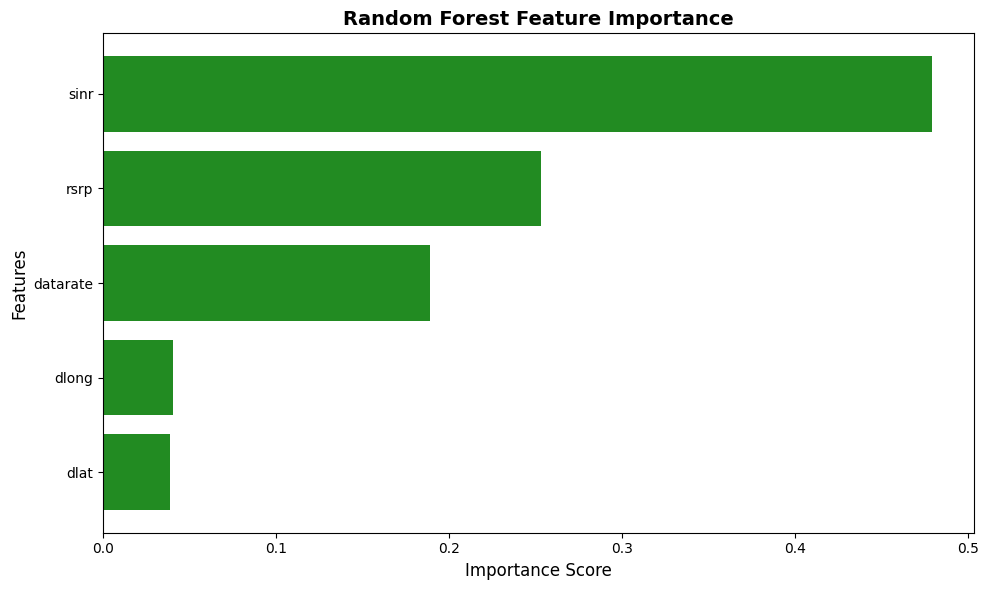

In [6]:
# Feature importance
rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance:")
print(rf_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color='forestgreen')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Train and Optimize XGBoost Model

Trains XGBoost using Bayesian Optimization to automatically search for optimal hyperparameters across 40 iterations. Computes predictions and evaluates model performance with the same metrics as Random Forest for direct comparison.

In [ ]:
    print("="*70)
    print("TRAINING XGBOOST MODEL")
    print("="*70)


    # Simple XGBoost model without GPU complications
    # XGBoost will automatically use the best available device
    # xgb_model = xgb.XGBRegressor(
    #     n_estimators=500,
    #     max_depth=10,
    #     learning_rate=0.1,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     min_child_weight=3,
    #     gamma=0.1,
    #     random_state=42,
    #     n_jobs=-1,  # Use all CPU cores
    #     tree_method='hist' , # Fast histogram-based algorithm
    #     device="cuda"

    # )
    xgb_search_space = {
        'n_estimators': Integer(200, 1000),
        'max_depth': Integer(4, 12),
        'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.6, 1.0),
        'min_child_weight': Integer(1, 10),
        'gamma': Real(0, 5),
        'reg_alpha': Real(0, 10),
        'reg_lambda': Real(0, 10)
    }
    xgb_base = xgb.XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        device='cuda',      # THIS is the GPU switch
        verbosity=0
    )


    print("Starting Bayesian Optimization for XGBoost...")
    print("This may take 15-20 minutes...")

    bayes_search_xgb = BayesSearchCV(
        xgb_base,
        xgb_search_space,
        n_iter=40,  # XGBoost requires more extensive hyperparameter search iterations
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=1,
        random_state=42,
        verbose=1
    )


    print("✓ XGBoost model initialized")

    # Train
    print("\nTraining XGBoost...")
    start_time = time.time()
    bayes_search_xgb.fit(X_train, y_train)
    xgb_training_time = time.time() - start_time
    xgb_model = bayes_search_xgb.best_estimator_
    xgb_training_time = time.time() - start_time

    print("\n" + "="*70)
    print("BEST XGBOOST PARAMETERS:")
    print("="*70)
    for param, value in bayes_search_xgb.best_params_.items():
        print(f"{param}: {value}")


    # Predict
    y_pred_xgb = xgb_model.predict(X_test)

    # Metrics
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    r2_xgb = r2_score(y_test, y_pred_xgb)

    print(f"\n{'='*70}")
    print("XGBOOST RESULTS:")
    print(f"{'='*70}")
    print(f"Training Time: {xgb_training_time:.2f} seconds")
    print(f"MAE (Mean Absolute Error): {mae_xgb:.4f} dB")
    print(f"RMSE (Root Mean Squared Error): {rmse_xgb:.4f} dB")
    print(f"R² Score: {r2_xgb:.4f} ({r2_xgb*100:.2f}% variance explained)")
    print(f"{'='*70}")


TRAINING XGBOOST MODEL
Starting Bayesian Optimization for XGBoost...
This may take 15-20 minutes...
✓ XGBoost model initialized

Training XGBoost...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each 

## Evaluate XGBoost Feature Importance

Analyzes the relative importance of each feature in the XGBoost model. Creates a ranked importance DataFrame and bar chart visualization to compare feature contributions.

XGBoost Feature Importance:
 Feature  Importance
    sinr    0.921191
    rsrp    0.030363
datarate    0.017443
    dlat    0.016973
   dlong    0.014030


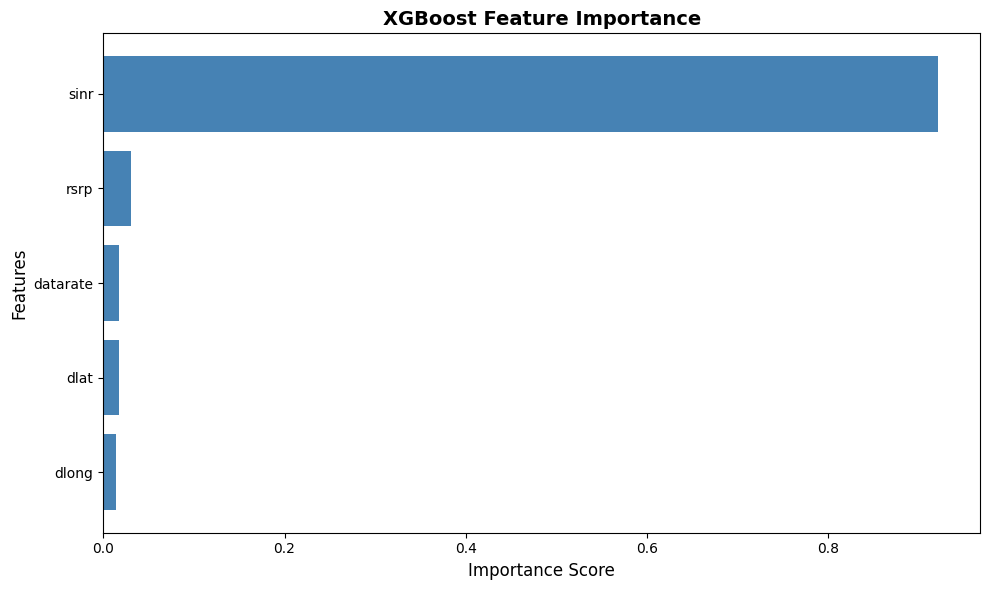

In [10]:
# Feature importance
xgb_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("XGBoost Feature Importance:")
print(xgb_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(xgb_importance['Feature'], xgb_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Compare Model Performance

Compares Random Forest and XGBoost models across multiple metrics (MAE, RMSE, R² Score, training time) in a unified comparison table. Creates side-by-side bar charts to identify the best performing model for RSRQ prediction.

MODEL COMPARISON
        Model  Training Time (s)  MAE (dB)  RMSE (dB)  R² Score
Random Forest          18.142649  0.764807   1.002518  0.801820
      XGBoost         432.426207  0.755280   0.989311  0.807007

 Best Model: XGBoost


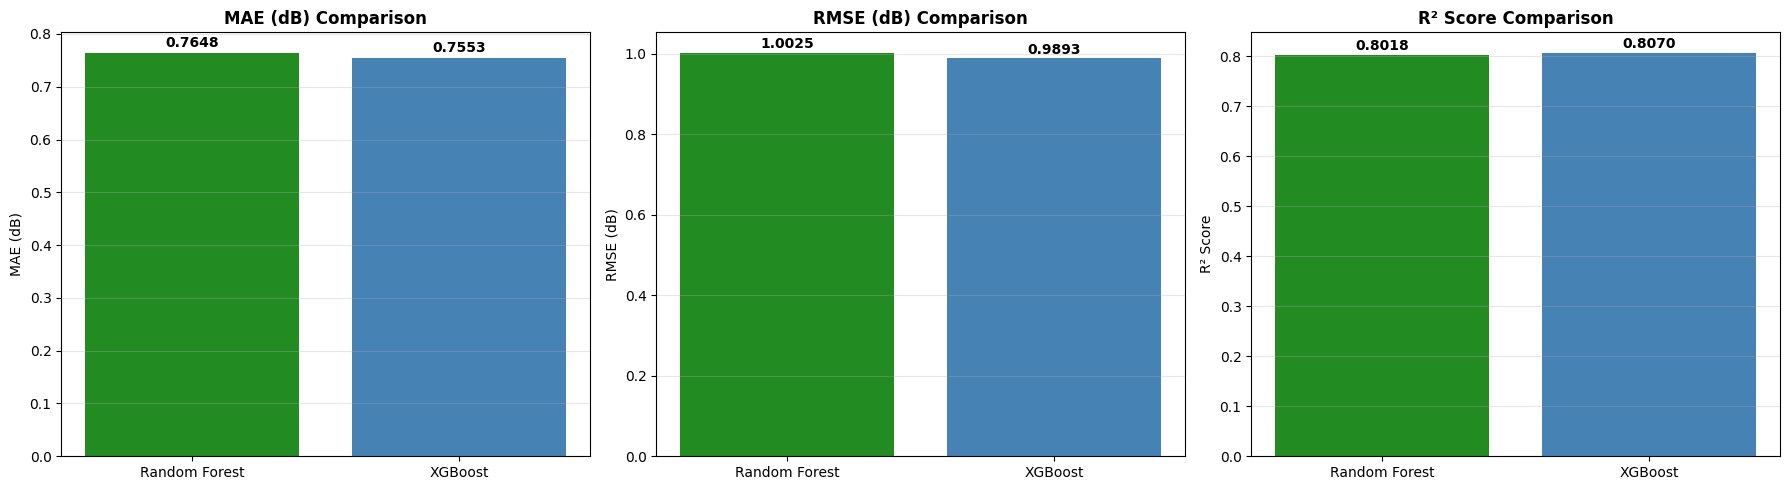

In [31]:
# Compare models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Training Time (s)': [rf_training_time, xgb_training_time],
    'MAE (dB)': [mae_rf, mae_xgb],
    'RMSE (dB)': [rmse_rf, rmse_xgb],
    'R² Score': [r2_rf, r2_xgb]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Determine best model
best_model_name = 'Random Forest' if mae_rf < mae_xgb else 'XGBoost'
best_model = rf_model if mae_rf < mae_xgb else xgb_model
y_pred_best = y_pred_rf if mae_rf < mae_xgb else y_pred_xgb

print(f"\n Best Model: {best_model_name}")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['MAE (dB)', 'RMSE (dB)', 'R² Score']
colors = ['forestgreen', 'steelblue']

for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison_df['Model'], comparison_df[metric], color=colors)
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## Visualize Predictions (Static Plots)

Creates static matplotlib visualizations comparing actual vs predicted RSRQ values. Includes a time-series line plot and a scatter plot with perfect prediction reference line for overall accuracy assessment.

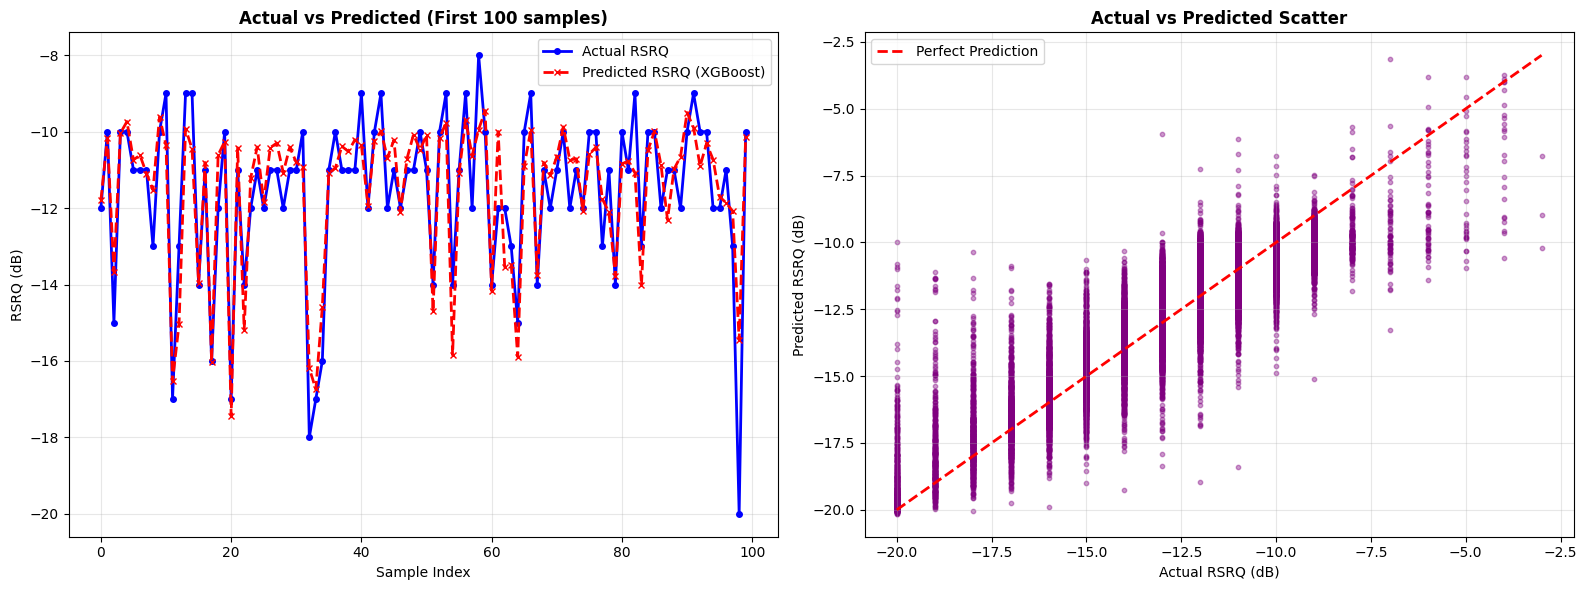

In [13]:
# Actual vs Predicted comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line plot (first 100 samples)
sample_size = 100
axes[0].plot(y_test.values[:sample_size], label='Actual RSRQ', 
             marker='o', linewidth=2, markersize=4, color='blue')
axes[0].plot(y_pred_best[:sample_size], label=f'Predicted RSRQ ({best_model_name})', 
             linestyle='--', marker='x', linewidth=2, markersize=4, color='red')
axes[0].set_title(f'Actual vs Predicted (First {sample_size} samples)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('RSRQ (dB)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter plot
axes[1].scatter(y_test, y_pred_best, alpha=0.4, s=10, color='purple')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Scatter', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual RSRQ (dB)')
axes[1].set_ylabel('Predicted RSRQ (dB)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Analyze Prediction Errors

Calculates residuals (errors) between actual and predicted values, then visualizes the error distribution with a histogram. Computes comprehensive error statistics including mean, standard deviation, percentiles, and error bounds for model validation.

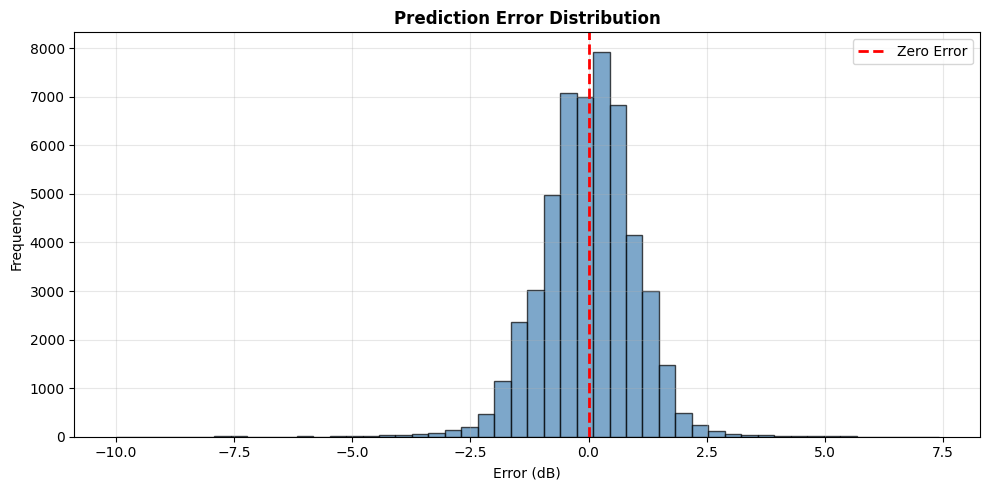

ERROR ANALYSIS
Mean Error: 0.0015 dB
Std Deviation: 0.9893 dB
Min Error: -9.9996 dB
Max Error: 7.4067 dB
Median Error: 0.0419 dB
25th Percentile: -0.5902 dB
75th Percentile: 0.6123 dB


In [30]:
# Calculate errors
errors = y_test.values - y_pred_best

# Error visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Histogram
ax.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_title('Prediction Error Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Error (dB)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error statistics
print("="*70)
print("ERROR ANALYSIS")
print("="*70)
print(f"Mean Error: {np.mean(errors):.4f} dB")
print(f"Std Deviation: {np.std(errors):.4f} dB")
print(f"Min Error: {np.min(errors):.4f} dB")
print(f"Max Error: {np.max(errors):.4f} dB")
print(f"Median Error: {np.median(errors):.4f} dB")
print(f"25th Percentile: {np.percentile(errors, 25):.4f} dB")
print(f"75th Percentile: {np.percentile(errors, 75):.4f} dB")
print("="*70)


## Create Interactive Visualization (Plotly)

Generates an interactive Plotly scatter plot with color-coded absolute errors for dynamic exploration of predictions. Includes metrics annotation and hover information for detailed sample-level inspection of prediction accuracy.

In [24]:
print("Creating interactive visualization with Plotly...")

import plotly.graph_objects as go

errors = y_test.values - y_pred_best
abs_errors = np.abs(errors)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test.values,
    y=y_pred_best,
    mode='markers',
    name='Predictions',
    marker=dict(
        size=5,
        color=abs_errors,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Absolute<br>Error (dB)"),
        opacity=0.6,
        line=dict(width=0.3, color='white')
    ),
    text=[f'Actual: {a:.2f} dB<br>Predicted: {p:.2f} dB<br>Error: {e:.2f} dB' 
          for a, p, e in zip(y_test.values, y_pred_best, errors)],
    hovertemplate='%{text}<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction',
    line=dict(color='red', width=2, dash='dash'),
    hoverinfo='skip'
))

mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

metrics_text = (
    f"<b>Model:</b> {best_model_name}<br>"
    f"<b>MAE:</b> {mae:.4f} dB<br>"
    f"<b>RMSE:</b> {rmse:.4f} dB<br>"
    f"<b>R²:</b> {r2:.4f}<br>"
    f"<b>Samples:</b> {len(y_test):,}"
)

fig.add_annotation(
    text=metrics_text,
    xref="paper", yref="paper",
    x=0.02, y=0.98,
    xanchor='left', yanchor='top',
    showarrow=False,
    bgcolor="rgba(255, 255, 255, 0.9)",
    bordercolor="black",
    borderwidth=1,
    font=dict(size=11, family="Arial")
)

fig.update_layout(
    title=f'{best_model_name}: Interactive Actual vs Predicted RSRQ',
    xaxis_title='Actual RSRQ (dB)',
    yaxis_title='Predicted RSRQ (dB)',
    hovermode='closest',
    width=900,
    height=600,
    template='plotly_white',
    showlegend=True,
    legend=dict(x=0.02, y=0.85, bgcolor='rgba(255,255,255,0.8)'),
    xaxis=dict(showgrid=True, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridcolor='lightgray')
)

import plotly.io as pio
pio.renderers.default = "browser"

fig.show()

fig.write_html('interactive_predictions.html')
print("✓ Interactive plot saved to 'interactive_predictions.html'")


Creating interactive visualization with Plotly...
Opening in existing browser session.
✓ Interactive plot saved to 'interactive_predictions.html'


## Generate Geospatial Heatmap (Actual RSRQ)

Creates an interactive folium map centered on test locations with color-coded heatmap overlay representing actual RSRQ signal quality. Normalizes RSRQ values and applies a gradient color scheme from red (poor signal) to green (excellent signal) for geographic visualization.

In [26]:
print("Creating geographic heatmap for Actual RSRQ...")

# Prepare data
heatmap_actual = pd.DataFrame({
    'lat': coords_test['lat'],
    'long': coords_test['long'],
    'rsrq': y_test_reset
})

# Remove any NaN values
heatmap_actual = heatmap_actual.dropna()

# Normalize RSRQ for color intensity (0-1 scale)
rsrq_min = heatmap_actual['rsrq'].min()
rsrq_max = heatmap_actual['rsrq'].max()
heatmap_actual['rsrq_norm'] = (heatmap_actual['rsrq'] - rsrq_min) / (rsrq_max - rsrq_min)

# Create base map centered on data
center_lat = heatmap_actual['lat'].mean()
center_long = heatmap_actual['long'].mean()

map_actual = folium.Map(
    location=[center_lat, center_long],
    zoom_start=12,
    tiles='OpenStreetMap'
)

# Prepare heatmap data: [[lat, long, intensity], ...]
heat_data_actual = heatmap_actual[['lat', 'long', 'rsrq_norm']].values.tolist()

# Add heatmap layer
HeatMap(
    heat_data_actual,
    min_opacity=0.4,
    max_zoom=18,
    radius=15,
    blur=20,
    gradient={
        0.0: 'red',      # Poor signal
        0.25: 'orange',
        0.5: 'yellow',   # Medium signal
        0.75: 'lightgreen',
        1.0: 'green'     # Excellent signal
    }
).add_to(map_actual)

# Add legend
legend_html = '''
<div style="position: fixed; top: 10px; right: 10px; width: 220px; height: 140px; 
     background-color: white; border:2px solid grey; z-index:9999; font-size:14px; padding: 10px">
     <b>Actual RSRQ Signal Quality</b><br><br>
     <i style="background: green; width: 20px; height: 10px; display: inline-block;"></i> Excellent (-3 to -10 dB)<br>
     <i style="background: lightgreen; width: 20px; height: 10px; display: inline-block;"></i> Good (-10 to -15 dB)<br>
     <i style="background: yellow; width: 20px; height: 10px; display: inline-block;"></i> Fair (-15 to -20 dB)<br>
     <i style="background: orange; width: 20px; height: 10px; display: inline-block;"></i> Poor (-20 to -25 dB)<br>
     <i style="background: red; width: 20px; height: 10px; display: inline-block;"></i> Very Poor (< -25 dB)<br>
</div>
'''
map_actual.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_actual.save('heatmap_actual_rsrq.html')
print(f"✓ Actual RSRQ heatmap saved to 'heatmap_actual_rsrq.html'")
print(f"  Data points: {len(heatmap_actual):,}")
print(f"  RSRQ range: {rsrq_min:.2f} to {rsrq_max:.2f} dB")


Creating geographic heatmap for Actual RSRQ...
✓ Actual RSRQ heatmap saved to 'heatmap_actual_rsrq.html'
  Data points: 51,096
  RSRQ range: -20.00 to -3.00 dB


## Persist Trained Models

Saves both trained models (Random Forest and XGBoost) to disk along with feature names and performance metrics. Uses joblib for sklearn models and native XGBoost format for model reloading and deployment in production.

In [27]:
print("="*70)
print("SAVING MODELS")
print("="*70)

# Save Random Forest
joblib.dump(rf_model, 'random_forest_model.pkl')
print("✓ Random Forest model saved to 'random_forest_model.pkl'")

# Save XGBoost
xgb_model.get_booster().save_model('xgboost_model.json')
print("✓ XGBoost model saved to 'xgboost_model.json'")

# Save feature list
import json
with open('features.json', 'w') as f:
    json.dump(features, f)
print("✓ Feature list saved to 'features.json'")

# Save model performance metrics
metrics = {
    'Random Forest': {
        'MAE': float(mae_rf),
        'RMSE': float(rmse_rf),
        'R2': float(r2_rf),
        'Training Time': float(rf_training_time)
    },
    'XGBoost': {
        'MAE': float(mae_xgb),
        'RMSE': float(rmse_xgb),
        'R2': float(r2_xgb),
        'Training Time': float(xgb_training_time)
    },
    'Best Model': best_model_name
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("✓ Model metrics saved to 'model_metrics.json'")

print("="*70)
print("All models saved successfully!")
print("="*70)


SAVING MODELS
✓ Random Forest model saved to 'random_forest_model.pkl'
✓ XGBoost model saved to 'xgboost_model.json'
✓ Feature list saved to 'features.json'
✓ Model metrics saved to 'model_metrics.json'
All models saved successfully!


## Load and Test Saved Models

Validation stage that loads all saved models, features, and metrics from disk. Performs inference on sample test data to verify model reproducibility.

In [28]:
print("="*70)
print("LOADING AND TESTING SAVED MODELS")
print("="*70)

# Load Random Forest
rf_loaded = joblib.load('random_forest_model.pkl')
print("✓ Random Forest model loaded")

# Load XGBoost
xgb_loaded = xgb.XGBRegressor()
xgb_loaded.load_model('xgboost_model.json')
print("✓ XGBoost model loaded")

# Load features
with open('features.json', 'r') as f:
    features_loaded = json.load(f)
print(f"✓ Features loaded: {features_loaded}")

# Load metrics
with open('model_metrics.json', 'r') as f:
    metrics_loaded = json.load(f)
print("✓ Model metrics loaded")

# Test with sample data
print("\n" + "="*70)
print("TESTING WITH SAMPLE DATA")
print("="*70)

sample = X_test.iloc[0:5]
actual = y_test.iloc[0:5]

print("\nSample Input Data:")
print(sample)

# Predictions
pred_rf_test = rf_loaded.predict(sample)
pred_xgb_test = xgb_loaded.predict(sample)

# Display results
results_test = pd.DataFrame({
    'Actual RSRQ': actual.values,
    'RF Prediction': pred_rf_test,
    'RF Error': actual.values - pred_rf_test,
    'XGB Prediction': pred_xgb_test,
    'XGB Error': actual.values - pred_xgb_test
})

print("\nPrediction Results:")
print(results_test.to_string(index=False))
print("="*70)


LOADING AND TESTING SAVED MODELS
✓ Random Forest model loaded
✓ XGBoost model loaded
✓ Features loaded: ['rsrp', 'sinr', 'datarate', 'dlat', 'dlong']
✓ Model metrics loaded

TESTING WITH SAMPLE DATA

Sample Input Data:
         rsrp  sinr     datarate      dlat     dlong
89422   -99.0   5.0   11570112.0 -0.000015 -0.000043
110037  -73.0  24.0  106694960.0 -0.000072 -0.000297
116496 -105.0  -5.0   14786408.0 -0.000050 -0.000491
96764   -63.0  21.0   63543230.0  0.000095  0.000355
119147  -78.0  16.0   44435070.0  0.000160 -0.000387

Prediction Results:
 Actual RSRQ  RF Prediction  RF Error  XGB Prediction  XGB Error
       -12.0     -11.994356 -0.005644      -11.795129  -0.204871
       -10.0     -10.137130  0.137130      -10.162324   0.162324
       -15.0     -13.880701 -1.119299      -13.662534  -1.337466
       -10.0     -10.082623  0.082623      -10.035803   0.035803
       -10.0      -9.642037 -0.357963       -9.735498  -0.264502


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 300 out of 300 | elapsed:    0.2s finished


## Generate Final Summary Report


In [29]:
print("="*70)
print("FINAL SUMMARY REPORT")
print("="*70)

print(f"\nDataset Information:")
print(f"   Total samples: {len(df_clean):,}")
print(f"   Training samples: {len(X_train):,}")
print(f"   Testing samples: {len(X_test):,}")
print(f"   Features used: {len(features)}")

print(f"\nModel Performance:")
print(f"\n   Random Forest:")
print(f"   • MAE: {mae_rf:.4f} dB")
print(f"   • RMSE: {rmse_rf:.4f} dB")
print(f"   • R² Score: {r2_rf:.4f} ({r2_rf*100:.2f}%)")
print(f"   • Training Time: {rf_training_time:.2f} seconds")

print(f"\n   XGBoost:")
print(f"   • MAE: {mae_xgb:.4f} dB")
print(f"   • RMSE: {rmse_xgb:.4f} dB")
print(f"   • R² Score: {r2_xgb:.4f} ({r2_xgb*100:.2f}%)")
print(f"   • Training Time: {xgb_training_time:.2f} seconds")

print(f"\n Best Model: {best_model_name}")


print("\n" + "="*70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)


FINAL SUMMARY REPORT

Dataset Information:
   Total samples: 255,479
   Training samples: 204,383
   Testing samples: 51,096
   Features used: 5

Model Performance:

   Random Forest:
   • MAE: 0.7648 dB
   • RMSE: 1.0025 dB
   • R² Score: 0.8018 (80.18%)
   • Training Time: 18.14 seconds

   XGBoost:
   • MAE: 0.7553 dB
   • RMSE: 0.9893 dB
   • R² Score: 0.8070 (80.70%)
   • Training Time: 432.43 seconds

 Best Model: XGBoost

PROJECT COMPLETED SUCCESSFULLY!
